In [1]:
setLatex = False

import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import curve_fit

#import pybinding as pb
import matplotlib.pyplot as plt
import numpy as np
import copy
import os
import re

import sys
from IPython.display import Math

from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
#rc('font',**{'family':'serif','serif':['Palatino']})
rc('text', usetex=True)

from importlib import reload
LongScripts = "/Users/nihao/Dropbox/Documents/Career/Calculs/Scripts/"
os.chdir(LongScripts)
import methodsLongitudinal as ml
reload(ml)


from copy import deepcopy

from scipy.spatial import cKDTree
from math import pi, sqrt
#from pybinding.repository.graphene import a, a_cc, t
import pickle
import scipy.ndimage.filters

import matplotlib

from pylab import *

import matplotlib.gridspec as gridspec


def latexify(fig_width=None, fig_height=None, columns=1):
    """Set up matplotlib's RC params for LaTeX plotting.
    Call this before plotting a figure.

    Parameters
    ----------
    fig_width : float, optional, inches
    fig_height : float,  optional, inches
    columns : {1, 2}
    """

    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf

    assert(columns in [1,2])

    if fig_width is None:
        fig_width = 3.39 if columns==1 else 6.9 # width in inches

    if fig_height is None:
        golden_mean = (sqrt(5)-1.0)/2.0    # Aesthetic ratio
        fig_height = fig_width*golden_mean # height in inches

    #MAX_HEIGHT_INCHES = 7.0
    #if fig_height > MAX_HEIGHT_INCHES:
    #    print("WARNING: fig_height too large:" + fig_height + 
    #          "so will reduce to" + MAX_HEIGHT_INCHES + "inches.")
    #    fig_height = MAX_HEIGHT_INCHES

    params = {'backend': 'ps',
              'text.latex.preamble': [r'\usepackage{gensymb}'],
              'axes.labelsize': 8, # fontsize for x and y labels (was 10)
              'axes.titlesize': 8,
              'font.size': 8, # was 10
              'legend.fontsize': 8, # was 10
              'xtick.labelsize': 8,
              'ytick.labelsize': 8,
              'text.usetex': True,
              'figure.figsize': [fig_width,fig_height],
              'font.family': 'serif',
              'figure.autolayout': True,
              'lines.linewidth' : 1.0
    }

    matplotlib.rcParams.update(params)


def format_axes(ax):
    
    SPINE_COLOR = 'gray'

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color(SPINE_COLOR)
        ax.spines[spine].set_linewidth(0.5)

    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_tick_params(direction='out', color=SPINE_COLOR)

#q_sigma = c0 * 22.2  # [nm] hopping fitting parameter
#q_pi = a_cc * 22.2  # [nm] hopping fitting parameter
#r0 = 0.184 * a  # [nm] hopping fitting parameter




from mpl_toolkits.axes_grid1 import make_axes_locatable


def getBandstructure(dir1, nPlotBands, EShift):

    f = open(dir1+'/generate.bands.dat','r')
    print(f)
    
    
    i = 0
    j = 0
    l = 0
    
    k = []
    E = []
    
    kVec = []
    EVec = []
    
    counterPlotBands = 0
    
    for line in f:
        i = i+1
        a = line.split()
        if i==10:
            nbands = int(a[5])
            print(nbands)
            nk = int(a[7])
            print(nbands,nk)
        if i>16:
            if len(a)==0:
                j = j+0.5
                #print(j)
            else:
                if (int(j)==int(nbands/2-nPlotBands/2 + counterPlotBands) and int(j) < int(nbands/2+nPlotBands/2)):
                    if l<nk:
                        k.append(float(a[0]))
                        E.append((float(a[1])-EShift))
                        l = l+1
                    if l==nk:
                        kVec.append(k)
                        EVec.append(E)
                        l = 0
                        counterPlotBands += 1
                        k = []
                        E = []
                        
    return kVec, EVec

def getSingleBand3(dir1, EShift, bandIndex):

    f = open(dir1+'/generate.bands.dat','r')
    
    
    i = 0
    j = 0
    l = 0
    
    k = []
    E = []
    
    kVec = []
    EVec = []
    
    counterPlotBands = 0
    
    for line in f:
        i = i+1
        a = line.split()
        if i==10:
            nbands = int(a[5])
            nk = int(a[7])
            #print(nbands,nk)
        if i>14:
            if len(a)==0:
                j = j+0.5
                #print(j)
            else:
                #print(nbands)
                if (int(j)==int(nbands/2) + bandIndex):
                    if l<nk:
                        k.append(float(a[0]))
                        E.append(float(a[1])-EShift)
                        l = l+1
                    if l==nk:
                        kVec.append(k)
                        EVec.append(E)
                        l = 0
                        counterPlotBands += 1
                        k = []
                        E = []
                        
    return kVec, EVec
                
def getGap(dir1, EShift):
    Emin = 10000000
    Emax = -10000000
    bandIndexVec = [-1]
    for bandIndex in bandIndexVec:
        kVec, EVec = getSingleBand3(dir1, EShift, bandIndex)
        i = 0
        if (np.max(EVec)>Emax):
            Emax = np.max(EVec)
        #if (np.min(EVec)<Emin):
        #    Emin= np.min(EVec)
    bandIndexVec = [0]
    for bandIndex in bandIndexVec:
        kVec, EVec = getSingleBand3(dir1, EShift, bandIndex)
        i = 0
        if (np.min(EVec)<Emin):
            Emin= np.min(EVec)
    gap = (Emin - Emax)*1000
    return gap

def getGap2(dir1, EShift):
    Emin = 10000000
    Emax = -10000000
    bandIndexVec = [-3]
    for bandIndex in bandIndexVec:
        kVec, EVec = getSingleBand3(dir1, EShift, bandIndex)
        i = 0
        if (np.max(EVec)>Emax):
            Emax = np.max(EVec)
        #if (np.min(EVec)<Emin):
        #    Emin= np.min(EVec)
    bandIndexVec = [-2]
    for bandIndex in bandIndexVec:
        kVec, EVec = getSingleBand3(dir1, EShift, bandIndex)
        i = 0
        if (np.min(EVec)<Emin):
            Emin= np.min(EVec)
    gap = (Emin - Emax)*1000
    return gap

def getEnergyCutPlot(dir1, chosenEnergy, Nx, Ny, cutoffMin, cutoffMax, nEnergy):

    os.chdir(dir1)
    

    data = np.genfromtxt("generate.spectral",skip_header=4)
    kx = data[:,0]
    ky = data[:,1]
    kz = data[:,2]
    energy = (data[:,3]*3.5)-0.31
    spectral = data[:,4]
    
    cutoffMin = cutoff
    cutoffMax = cutoff
    
    i = 0
    j = 0
    eigVec = []
    spectralVec = []
    
    eig = np.zeros(nEnergy)
    spect = np.zeros(nEnergy)
    k = np.zeros(shape=(Nx*Ny,2))
    
    for el1, el2, el3, el4 in zip(kx,ky,energy,spectral):
        i = i+1
        if (i==1):
            k[j,0] = el1
            k[j,1] = el2
        if (i<=nEnergy):
            eig[i-1] = el3
            spect[i-1] = el4
        if (i==nEnergy):
            eigVec.append(eig)
            spectralVec.append(spect)
            i = 0
            j = j+1
            eig = np.zeros(nEnergy)
            spect = np.zeros(nEnergy)
        
    
    eigTrueVec = []
    for i, kki in enumerate(k):
        eigTrue = np.zeros(nEnergy)
        eig = eigVec[i]
        spec = spectralVec[i]
        eigTrue[np.logical_and(np.logical_and(eig>chosenEnergy-cutoffMin,eig<chosenEnergy+cutoffMax),spec>0.0)] = 1.0
        specSum = np.sum(spec[np.logical_and(np.logical_and(eig>chosenEnergy-cutoffMin,eig<chosenEnergy+cutoffMax),spec>0.0)])
        if (eigTrue.any()==1):
            eigTrueVec.append(specSum)
        else:
            eigTrueVec.append(0)
       

    return k, eigTrueVec    
    
K1 = np.array([1.70276024584813, 0.0000])
K1p = np.array([1.70243417150001, 3.332186294066186E-002])


def getEnergyCutPlot2(dir1, chosenEnergy, Nx, Ny, cutoffMin, cutoffMax, nEnergy):

    os.chdir(dir1)
    

    data = np.genfromtxt("generate.spectral")
    kx = data[:,0]
    ky = data[:,1]
    kz = data[:,2]
    energy = (data[:,3]*3.5)-0.31
    spectral = data[:,4]
    
    cutoffMin = cutoff
    cutoffMax = cutoff
    
    i = 0
    j = 0
    eigVec = []
    spectralVec = []
    
    eig = np.zeros(nEnergy)
    spect = np.zeros(nEnergy)
    k = np.zeros(shape=(Nx*Ny,2))
    
    for el1, el2, el3, el4 in zip(kx,ky,energy,spectral):
        i = i+1
        if (i==1):
            k[j,0] = el1
            k[j,1] = el2
        if (i<=nEnergy):
            eig[i-1] = el3
            spect[i-1] = el4
        if (i==nEnergy):
            eigVec.append(eig)
            spectralVec.append(spect)
            i = 0
            j = j+1
            eig = np.zeros(nEnergy)
            spect = np.zeros(nEnergy)
        
    
    eigTrueVec = []
    for i, kki in enumerate(k):
        eigTrue = np.zeros(nEnergy)
        eig = eigVec[i]
        spec = spectralVec[i]
        eigTrue[np.logical_and(np.logical_and(eig>chosenEnergy-cutoffMin,eig<chosenEnergy+cutoffMax),spec>0.0)] = 1.0
        specSum = np.sum(spec[np.logical_and(np.logical_and(eig>chosenEnergy-cutoffMin,eig<chosenEnergy+cutoffMax),spec>0.0)])
        if (eigTrue.any()==1):
            eigTrueVec.append(specSum)
        else:
            eigTrueVec.append(0)
       

    return k, eigTrueVec    

def getDOS(fileName):
    data = np.genfromtxt(fileName)
    xdata = data[:,0]
    ydata = data[:,1]
    return xdata, ydata
    
K1 = np.array([1.70276024584813, 0.0000])
K1p = np.array([1.70243417150001, 3.332186294066186E-002])


# Graphene

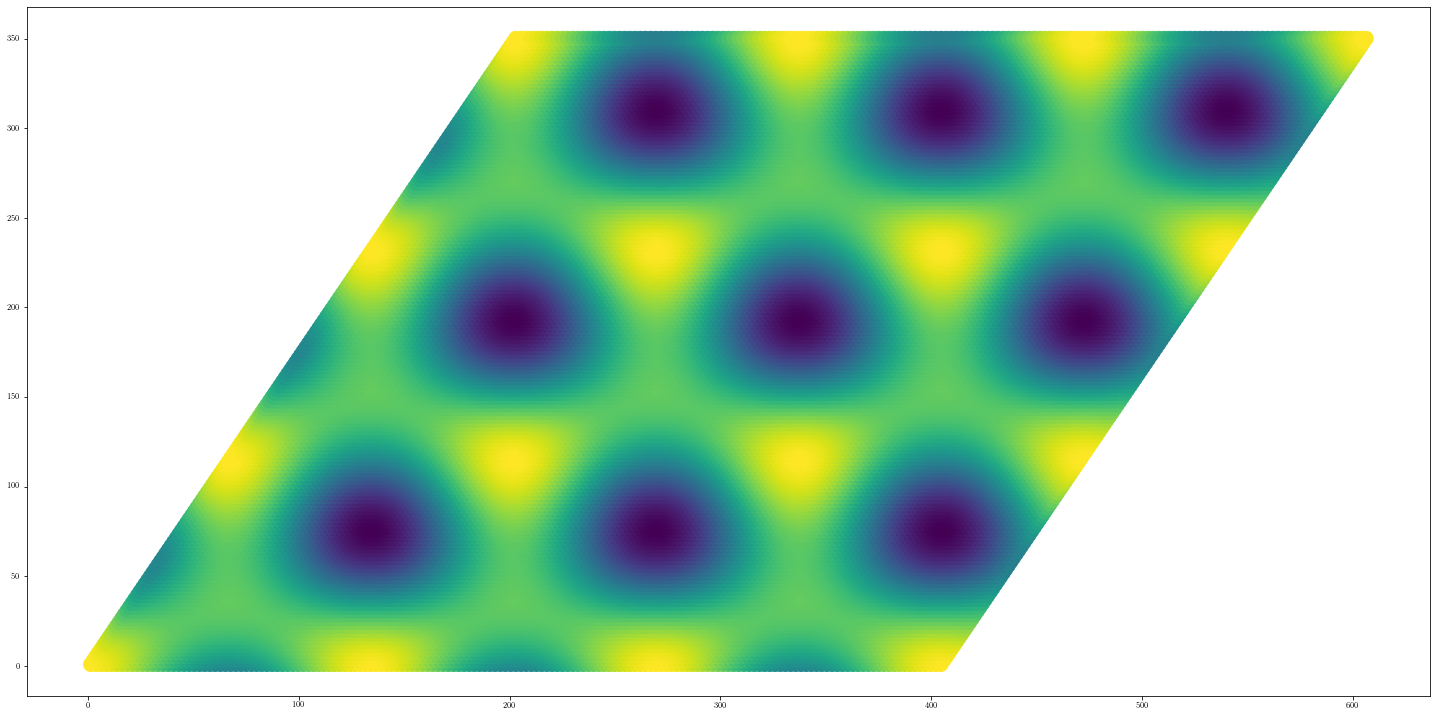

In [37]:
os.chdir("/Users/nihao/github/moire_course/grabnes2/inputFiles/graphene/effectiveGBN/")

data = np.genfromtxt("generate.pos")
xdata = data[:,0][::2]
ydata = data[:,1][::2]

data = np.genfromtxt("generate.e")
zdata = data[:,0][::2]

plt.figure(figsize=(20,10))
plt.scatter(xdata, ydata, c=zdata,s=200)#,cmap="gist_ncar")

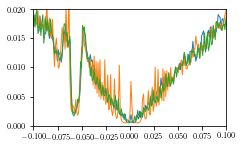

In [53]:
os.chdir("/Users/nihao/github/moire_course/grabnes2/inputFiles/graphene/LL/m00005/")

xdata, ydata = getDOS("generate.DOS")
plt.plot(xdata,ydata,label="0.2 T")

os.chdir("/Users/nihao/github/moire_course/grabnes2/inputFiles/graphene/LL/m00020/")

xdata, ydata = getDOS("generate.DOS")
plt.plot(xdata,ydata,label="0.8 T")

os.chdir("/Users/nihao/github/moire_course/grabnes2/outputFiles/graphene/SC30/")

xdata, ydata = getDOS("generate.DOS")
plt.plot(xdata,ydata,label="0 T")

plt.xlim(-0.1,0.1)
plt.ylim(0,0.02)

os.chdir("/Users/nihao/github/moire_course/grabnes2/outputFiles/graphene/diag/")

xdata, ydata = getDOS("generate.diag.DOS")
#plt.plot(xdata,ydata)

<_io.TextIOWrapper name='/Users/nihao/github/moire_course/grabnes2/inputFiles/graphene/diag/bands//generate.bands.dat' mode='r' encoding='UTF-8'>
6050
6050 15


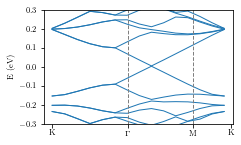

In [50]:
nPlotBands = 40

ncol = 1
nrow = 1

emin = -0.3
emax = 0.3

#emin = -0.002
#emax = 0.007

latexify(columns=1)#, fig_height=1.7)  

g1 = gridspec.GridSpec(nrow, ncol)#, height_ratios=[6,1])
g1.update(wspace=0.15, hspace=0.0) # set the spacing between axes.

fig, ((ax0)) = plt.subplots(nrow, ncol, sharex='col', sharey='row')

ax0 = subplot(g1[0]) 


kpoint = 0.0
gpoint = 0.032230
mpoint = 0.060143
kppoint = 0.076259



factor = kppoint
max1_08 = 0.078838
max1_12 = 0.078838

EShift = 0
dir1 = "/Users/nihao/github/moire_course/grabnes2/inputFiles/graphene/diag/bands/"#/useReadXYZ/"
kVec, EVec = getBandstructure(dir1, nPlotBands, EShift)
i = 0
for el1, el2 in zip(kVec,EVec):
    i = i+1
    if (i==1):
        #ax0.plot(el1, el2,color="C1",label=r"KC$_{VV10}$")
        ax0.plot(el1, el2,color="C0",label=r"GBN")
    else:
        ax0.plot(el1, el2,color="C0")
        
#dir1 = "/Users/nihao/Dropbox/Documents/Career/Calculs/twistedBilayer/substrate/RPA/freestandingMagic/"
#dir1 = "/Users/nihao/Dropbox/Documents/Career/Calculs/twistedBilayer/substrate/RPA/freestandingStrained/again/"
#dir1 = "/Users/nihao/github/moire_course/grabnes2/outputFiles/tBG//useReadXYZ/"
#kVec, EVec = getBandstructure(dir1, nPlotBands, EShift)
#i = 0
#for el1, el2 in zip(kVec,EVec):
#    i = i+1
#    if (i==1):
#        ax0.plot(el1, el2,"--",color="C1",label=r"REBO2")
#    else:
#        ax0.plot(el1, el2,"--",color="C1")
        
#EShift = 0.299
#dir1 = "/Users/nihao/Dropbox/Documents/Career/Calculs/twistedBilayer/substrate/RPA/freestandingMagicStrained/"
#kVec, EVec = getBandstructure(dir1, nPlotBands, EShift)
#i = 0
#for el1, el2 in zip(kVec,EVec):
#    i = i+1
#    if (i==1):
#        ax0.plot(el1, el2,".-",color="C2",label=r"Rebo (renormalized)")
#    else:
#        ax0.plot(el1, el2,".-",color="C2")
        
        

       
        
    
ax0.set_ylim([emin,emax])
#ax0.set_xlim([kpoint,kppoint])
ax0.set_xticks([kpoint, gpoint, mpoint, kppoint])
ax0.set_xticklabels(["K",r"$\Gamma$","M","K"])
##ax0.set_yticklabels([" "])
ax0.axvline(gpoint,linestyle="dashed",color="grey")
ax0.axvline(mpoint,linestyle="dashed",color="grey")
#
#
ax0.set_ylabel("E (eV)")
#
#ax0.legend(loc=(0.26,0.05))
#ax1.legend(loc=0)
#ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))

#ax0.set_title(r"Drip$^\textrm{Bi}_\textrm{RPA}$")


#os.chdir("/Users/nihao/Dropbox/Projects/RPADripCalculations/Figures")
#os.chdir("/Users/nihao/Dropbox/Apps/Overleaf/Magic Angle Twisted Bilayer Graphene Electronic Structure based on Random Phase Approximation calculations/")
os.chdir("/Users/nihao/Desktop/")
fig.savefig("gap2020tBG.png",dpi=400,bbox_inches="tight")

# tBG

<_io.TextIOWrapper name='/Users/nihao/github/moire_course/grabnes2/outputFiles/tBG//generate.bands.dat' mode='r' encoding='UTF-8'>
1084
1084 48
<_io.TextIOWrapper name='/Users/nihao/github/moire_course/grabnes2/outputFiles/tBG//useReadXYZ//generate.bands.dat' mode='r' encoding='UTF-8'>
1084
1084 25


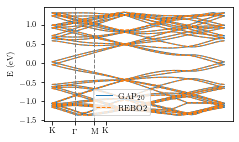

In [12]:
nPlotBands = 40

ncol = 1
nrow = 1

emin = -0.2
emax = 0.2

#emin = -0.002
#emax = 0.007

latexify(columns=1)#, fig_height=1.7)  

g1 = gridspec.GridSpec(nrow, ncol)#, height_ratios=[6,1])
g1.update(wspace=0.15, hspace=0.0) # set the spacing between axes.

fig, ((ax0)) = plt.subplots(nrow, ncol, sharex='col', sharey='row')

ax0 = subplot(g1[0]) 


kpoint = 0.0
gpoint = 0.032230
mpoint = 0.060143
kppoint = 0.076259



factor = kppoint
max1_08 = 0.078838
max1_12 = 0.078838

EShift = 0.302
dir1 = "/Users/nihao/github/moire_course/grabnes2/outputFiles/tBG/"#/useReadXYZ/"
kVec, EVec = getBandstructure(dir1, nPlotBands, EShift)
i = 0
for el1, el2 in zip(kVec,EVec):
    i = i+1
    if (i==1):
        #ax0.plot(el1, el2,color="C1",label=r"KC$_{VV10}$")
        ax0.plot(el1, el2,color="C0",label=r"GAP$_{20}$")
    else:
        ax0.plot(el1, el2,color="C0")
        
#dir1 = "/Users/nihao/Dropbox/Documents/Career/Calculs/twistedBilayer/substrate/RPA/freestandingMagic/"
#dir1 = "/Users/nihao/Dropbox/Documents/Career/Calculs/twistedBilayer/substrate/RPA/freestandingStrained/again/"
dir1 = "/Users/nihao/github/moire_course/grabnes2/outputFiles/tBG//useReadXYZ/"
kVec, EVec = getBandstructure(dir1, nPlotBands, EShift)
i = 0
for el1, el2 in zip(kVec,EVec):
    i = i+1
    if (i==1):
        ax0.plot(el1, el2,"--",color="C1",label=r"REBO2")
    else:
        ax0.plot(el1, el2,"--",color="C1")
        
#EShift = 0.299
#dir1 = "/Users/nihao/Dropbox/Documents/Career/Calculs/twistedBilayer/substrate/RPA/freestandingMagicStrained/"
#kVec, EVec = getBandstructure(dir1, nPlotBands, EShift)
#i = 0
#for el1, el2 in zip(kVec,EVec):
#    i = i+1
#    if (i==1):
#        ax0.plot(el1, el2,".-",color="C2",label=r"Rebo (renormalized)")
#    else:
#        ax0.plot(el1, el2,".-",color="C2")
        
        

       
        
    
#ax0.set_ylim([emin,emax])
#ax0.set_xlim([kpoint,kppoint])
ax0.set_xticks([kpoint, gpoint, mpoint, kppoint])
ax0.set_xticklabels(["K",r"$\Gamma$","M","K"])
##ax0.set_yticklabels([" "])
ax0.axvline(gpoint,linestyle="dashed",color="grey")
ax0.axvline(mpoint,linestyle="dashed",color="grey")
#
#
ax0.set_ylabel("E (eV)")
#
ax0.legend(loc=(0.26,0.05))
#ax1.legend(loc=0)
#ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))

#ax0.set_title(r"Drip$^\textrm{Bi}_\textrm{RPA}$")


#os.chdir("/Users/nihao/Dropbox/Projects/RPADripCalculations/Figures")
#os.chdir("/Users/nihao/Dropbox/Apps/Overleaf/Magic Angle Twisted Bilayer Graphene Electronic Structure based on Random Phase Approximation calculations/")
os.chdir("/Users/nihao/Desktop/")
fig.savefig("gap2020tBG.png",dpi=400,bbox_inches="tight")

<_io.TextIOWrapper name='/Users/nihao/github/moire_course/grabnes2/outputFiles/tBG/n31//generate.bands.dat' mode='r' encoding='UTF-8'>
11164
11164 13
<_io.TextIOWrapper name='/Users/nihao/github/moire_course/grabnes2/outputFiles/tBG/n31/useReadXYZ//generate.bands.dat' mode='r' encoding='UTF-8'>
11164
11164 25


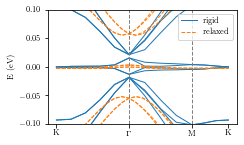

In [46]:
nPlotBands = 40

ncol = 1
nrow = 1

emin = -0.1
emax = 0.1

#emin = -0.002
#emax = 0.007

latexify(columns=1)#, fig_height=1.7)  

g1 = gridspec.GridSpec(nrow, ncol)#, height_ratios=[6,1])
g1.update(wspace=0.15, hspace=0.0) # set the spacing between axes.

fig, ((ax0)) = plt.subplots(nrow, ncol, sharex='col', sharey='row')

ax0 = subplot(g1[0]) 


kpoint = 0.0
gpoint = 0.032230
mpoint = 0.060143
kppoint = 0.076259



factor = kppoint
max1_08 = 0.078838
max1_12 = 0.078838

EShift = 0.302
dir1 = "/Users/nihao/github/moire_course/grabnes2/outputFiles/tBG/n31/"#/useReadXYZ/"
kVec, EVec = getBandstructure(dir1, nPlotBands, EShift)
i = 0
for el1, el2 in zip(kVec,EVec):
    i = i+1
    if (i==1):
        #ax0.plot(el1, el2,color="C1",label=r"KC$_{VV10}$")
        ax0.plot(el1, el2,color="C0",label=r"rigid")
    else:
        ax0.plot(el1, el2,color="C0")
        
#dir1 = "/Users/nihao/Dropbox/Documents/Career/Calculs/twistedBilayer/substrate/RPA/freestandingMagic/"
#dir1 = "/Users/nihao/Dropbox/Documents/Career/Calculs/twistedBilayer/substrate/RPA/freestandingStrained/again/"
dir1 = "/Users/nihao/github/moire_course/grabnes2/outputFiles/tBG/n31/useReadXYZ/"
kVec, EVec = getBandstructure(dir1, nPlotBands, EShift)
i = 0
for el1, el2 in zip(kVec,EVec):
    i = i+1
    if (i==1):
        ax0.plot(el1, el2,"--",color="C1",label=r"relaxed")
    else:
        ax0.plot(el1, el2,"--",color="C1")
        
#EShift = 0.299
#dir1 = "/Users/nihao/Dropbox/Documents/Career/Calculs/twistedBilayer/substrate/RPA/freestandingMagicStrained/"
#kVec, EVec = getBandstructure(dir1, nPlotBands, EShift)
#i = 0
#for el1, el2 in zip(kVec,EVec):
#    i = i+1
#    if (i==1):
#        ax0.plot(el1, el2,".-",color="C2",label=r"Rebo (renormalized)")
#    else:
#        ax0.plot(el1, el2,".-",color="C2")
        
        

       
        
    
ax0.set_ylim([emin,emax])
#ax0.set_xlim([kpoint,kppoint])
ax0.set_xticks([kpoint, gpoint, mpoint, kppoint])
ax0.set_xticklabels(["K",r"$\Gamma$","M","K"])
##ax0.set_yticklabels([" "])
ax0.axvline(gpoint,linestyle="dashed",color="grey")
ax0.axvline(mpoint,linestyle="dashed",color="grey")
#
#
ax0.set_ylabel("E (eV)")
#
#ax0.legend(loc=(0.26,0.05))
ax0.legend(loc=0)
#ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))

#ax0.set_title(r"Drip$^\textrm{Bi}_\textrm{RPA}$")


#os.chdir("/Users/nihao/Dropbox/Projects/RPADripCalculations/Figures")
#os.chdir("/Users/nihao/Dropbox/Apps/Overleaf/Magic Angle Twisted Bilayer Graphene Electronic Structure based on Random Phase Approximation calculations/")
os.chdir("/Users/nihao/Desktop/")
fig.savefig("gap2020tBG.png",dpi=400,bbox_inches="tight")

(0.0, 1000.0)

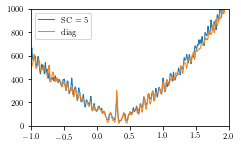

In [43]:
os.chdir("/Users/nihao/github/moire_course/grabnes2/outputFiles/tBG/n31/DOS/")

xdata, ydata = getDOS("generate.DOS")
#plt.plot(xdata*3.5,ydata*11164/3.5*2,label="SC = 1")

os.chdir("/Users/nihao/github/moire_course/grabnes2/outputFiles/tBG/n31/DOS/SC20/")

xdata, ydata = getDOS("generate.DOS")
plt.plot(xdata*3.5,ydata*11164/3.5*2,label="SC = 5")



os.chdir("/Users/nihao/github/moire_course/grabnes2/outputFiles/tBG/n31/DOS/diagDOS/")

xdata, ydata = getDOS("generate.diag.DOS")
plt.plot(xdata,ydata, label="diag")

plt.legend()

plt.xlim(-1.0,2.0)
plt.ylim(0,1000)